# Customer Churn Analysis

## Understanding Customer Retention and Revenue Risk

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
df = pd.read_csv("data/churn_data.csv")
df.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("churn_data.csv")
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True


In [4]:
df.shape

(5043, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   str    
 2   gender            5043 non-null   str    
 3   SeniorCitizen     5043 non-null   str    
 4   Partner           5043 non-null   str    
 5   Dependents        5043 non-null   str    
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   str    
 8   MultipleLines     4774 non-null   str    
 9   InternetService   5043 non-null   str    
 10  OnlineSecurity    4392 non-null   str    
 11  OnlineBackup      4392 non-null   str    
 12  DeviceProtection  4392 non-null   str    
 13  TechSupport       4392 non-null   str    
 14  StreamingTV       4392 non-null   str    
 15  StreamingMovies   4392 non-null   str    
 16  Contract          5043 non-null   str    
 17  Paperl

In [6]:
df.describe()

,Unnamed: 0,tenure,MonthlyCharges
count,5043.000000,5043.000000,5043.000000
mean,1305.651993,32.576641,65.090214
std,801.484415,24.529807,30.068133
min,0.000000,0.000000,18.400000
25%,630.000000,9.000000,35.775000
50%,1260.000000,29.000000,70.550003
75%,1890.500000,56.000000,90.050003
max,2999.000000,72.000000,118.650002


In [7]:
df.isnull().sum()

Unnamed: 0            0
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          5
Churn                 1
dtype: int64

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [9]:
df.isnull().sum()

Unnamed: 0            0
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          8
Churn                 1
dtype: int64

In [10]:
df = df.dropna()

In [11]:
df.shape

(4118, 22)

In [12]:
df["churn_flag"] = df["Churn"].map({"Yes": 1, "No": 0})

In [13]:
df[["Churn", "churn_flag"]].head()

,Churn,churn_flag
1,False,NaN
2,True,NaN
4,True,NaN
5,True,NaN
6,False,NaN


In [14]:
df["churn_flag"].mean()

np.float64(0.2725490196078431)

In [15]:
df.groupby("Contract")["churn_flag"].mean().sort_values(ascending=False)

Contract
Month-to-month    0.437897
One year          0.120181
Two year          0.040323
Name: churn_flag, dtype: float64

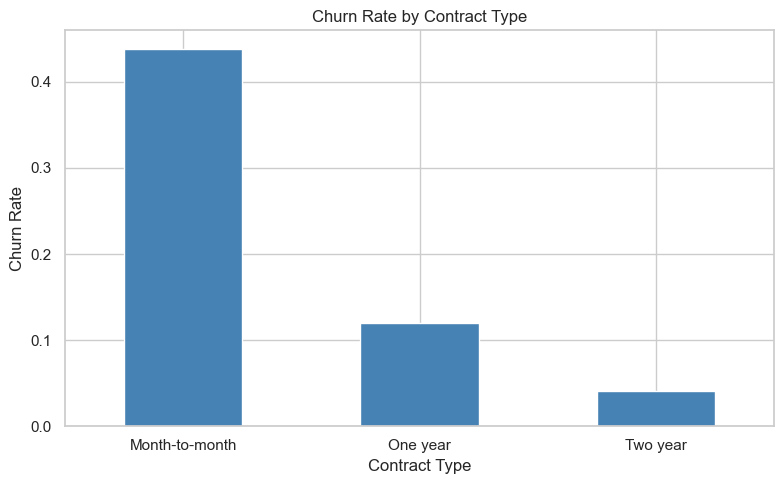

In [16]:
contract_churn = df.groupby("Contract")["churn_flag"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
contract_churn.plot(kind="bar", color="steelblue")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("churn_rate_by_contract.png", dpi=300)

plt.show()

In [17]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
False    81.685414
No       61.282648
True     83.108580
Yes      73.937680
Name: MonthlyCharges, dtype: float64

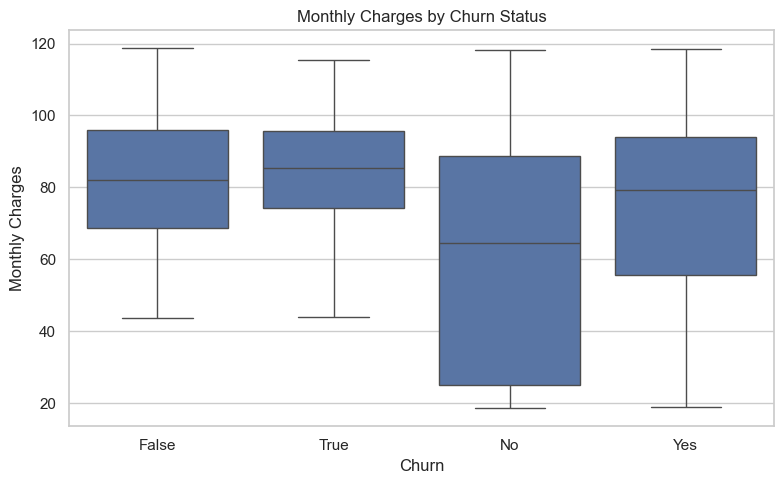

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig("monthly_charges_by_churn.png", dpi=300)

plt.show()

In [19]:
df.groupby("Churn")["tenure"].mean()

Churn
False    39.805278
No       37.992588
True     18.909763
Yes      18.562950
Name: tenure, dtype: float64

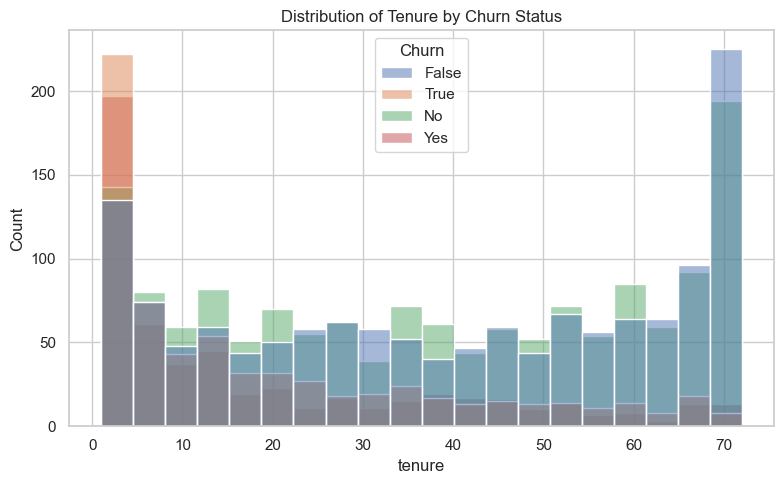

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", hue="Churn", bins=20, kde=False)

plt.title("Distribution of Tenure by Churn Status")

plt.tight_layout()

plt.savefig("churn_by_tenure.png", dpi=300)

plt.show()

In [21]:
df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

np.float64(41109.350000000006)

In [22]:
df[df["Churn"] == "Yes"].groupby("Contract")["MonthlyCharges"].sum()

Contract
Month-to-month    34807.90
One year           4519.15
Two year           1782.30
Name: MonthlyCharges, dtype: float64

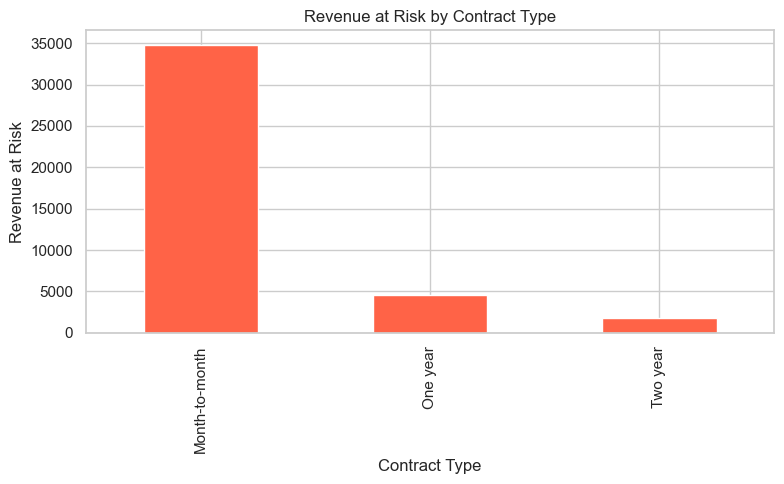

In [23]:
revenue_risk = df[df["Churn"] == "Yes"].groupby("Contract")["MonthlyCharges"].sum()

plt.figure(figsize=(8,5))

revenue_risk.plot(kind="bar", color="tomato")

plt.title("Revenue at Risk by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Revenue at Risk")

plt.tight_layout()

plt.savefig("revenue_at_risk.png", dpi=300)

plt.show()